# Machine Learning vs Traditional Financial Models

*Quant Lab · The Analytical Investor · Year 1, Month 12*

**Read the article:** [Machine Learning vs Traditional Financial Models](https://analytical-investor.blog/?p=1039)

Ridge regression against gradient boosting in two worlds: a signal-rich, stable one and a market-like one with weak, drifting signal. Allow about a minute to run.

> Run locally with `pip install -e ".[notebooks]"` from the repo root, then open this notebook in Jupyter. All data is simulated with fixed seeds, so every number matches the article.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9, 5), "axes.grid": True, "grid.alpha": 0.3})

## Step 1
Run both worlds.

In [2]:
import numpy as np
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import Ridge

rng = np.random.default_rng(55)

def experiment(n_train, n_test, n_feat, r2_true, nonlinear, drift):
    """Compare Ridge vs Gradient Boosting under chosen conditions."""
    n = n_train + n_test
    X = rng.normal(size=(n, n_feat))
    beta = rng.normal(size=n_feat) / np.sqrt(n_feat)

    signal = 0.5 * (X @ beta)              # a modest linear component...
    if nonlinear:                          # ...plus strong interactions & thresholds
        signal += 1.5*np.tanh(X[:,0]*X[:,1]) + 1.5*(X[:,2] > 0.5)*X[:,3]
    if drift:                              # regime change mid-sample
        signal[n//2:] = signal[n//2:] * -0.3   # relationships decay/flip

    signal = (signal - signal.mean()) / signal.std()
    noise = rng.normal(size=n)
    y = np.sqrt(r2_true)*signal + np.sqrt(1-r2_true)*noise

    Xtr, Xte, ytr, yte = X[:n_train], X[n_train:], y[:n_train], y[n_train:]
    out = {}
    for name, model in [("Ridge", Ridge(alpha=1.0)),
                        ("GBM", GradientBoostingRegressor(
                            n_estimators=300, max_depth=3,
                            learning_rate=0.05, subsample=0.7,
                            random_state=0))]:
        model.fit(Xtr, ytr)
        pred = model.predict(Xte)
        ss = 1 - ((yte-pred)**2).sum() / ((yte-yte.mean())**2).sum()
        out[name] = round(float(ss), 3)
    return out

print("=== World A: vision-like (high signal, stable, nonlinear) ===")
print(experiment(20_000, 5_000, 20, r2_true=0.60,
                 nonlinear=True, drift=False))

print("\n=== World B: market-like (low signal, drifting) ===")
for trial in range(5):
    print(experiment(2_000, 500, 20, r2_true=0.03,
                     nonlinear=True, drift=True))

=== World A: vision-like (high signal, stable, nonlinear) ===


{'Ridge': 0.189, 'GBM': 0.53}

=== World B: market-like (low signal, drifting) ===


{'Ridge': -0.04, 'GBM': -0.144}


{'Ridge': -0.013, 'GBM': -0.033}


{'Ridge': -0.017, 'GBM': -0.07}


{'Ridge': -0.037, 'GBM': -0.072}


{'Ridge': -0.002, 'GBM': -0.059}


### Where does flexibility start paying?
A fresh sweep (new random draws, so not the article's exact numbers) over signal strength, with no regime drift.

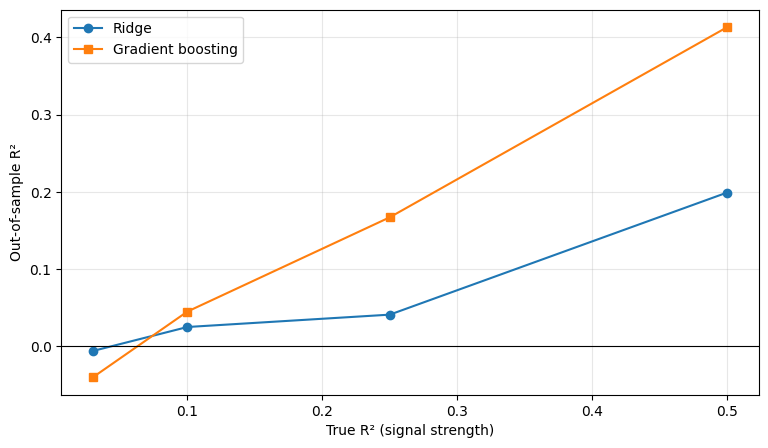

In [3]:
r2s = [0.03, 0.10, 0.25, 0.50]
res = [experiment(4_000, 1_000, 20, r2_true=q, nonlinear=True, drift=False) for q in r2s]
plt.plot(r2s, [x["Ridge"] for x in res], "o-", label="Ridge")
plt.plot(r2s, [x["GBM"] for x in res], "s-", label="Gradient boosting")
plt.axhline(0, color="k", lw=0.8)
plt.xlabel("True R² (signal strength)"); plt.ylabel("Out-of-sample R²"); plt.legend(); plt.show()

---
The article's **Limitations** section explains what this model leaves out. [Read it here](https://analytical-investor.blog/?p=1039).